In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import glob, sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parents[2]))
from utils.notebook import display_plot, format_metric

In [9]:
import glob, json

eps = 0.01
vehicles = glob.glob("../data-test/randpos/clean/*")
# vehicles = glob.glob(f"../data-test/randpos/fgsm/eps-{eps}/*")

f1_scores = []

for veh_file in vehicles:
    with open(veh_file, "r") as veh:
        veh_json = json.load(veh)
        f1_scores.append(veh_json["wrapper"]["f1"])
        # f1_scores.append(veh_json["metrics"]["f1"])

f1_avg = sum(f1_scores) / len(f1_scores)

f1_avg

0.8985207325028302

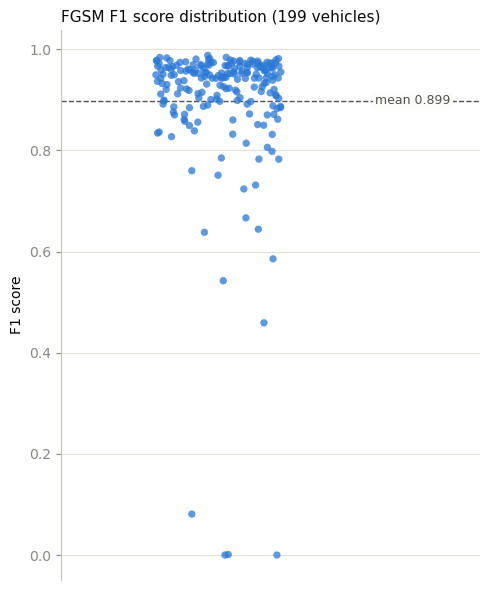

In [10]:
# Point plot of the per-vehicle F1 scores, to see the distribution behind f1_avg
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 6))

rng = np.random.default_rng(0)
jitter = rng.uniform(-0.12, 0.12, size=len(f1_scores))

ax.scatter(jitter, f1_scores, s=28, facecolor="#2a78d6", edgecolor="none", alpha=0.75, zorder=3)

mean_f1 = float(np.mean(f1_scores))
ax.axhline(mean_f1, color="#52514e", linestyle="--", linewidth=1, zorder=2)
ax.text(0.3, mean_f1, f"mean {mean_f1:.3f}", color="#52514e", fontsize=9,
        va="center", ha="left",
        bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1.5))

ax.set_xlim(-0.3, 0.5)
ax.set_xticks([])
ax.set_ylabel("F1 score")
ax.set_title(f"FGSM F1 score distribution ({len(f1_scores)} vehicles)",
             fontsize=11, color="#0b0b0b", loc="left")

for spine in ("top", "right", "bottom"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
import glob, json
x_vals = []
y_vals = []

metric = "falseNegativeRate"

# Clean case
vehicles = glob.glob("../data-test/randpos/clean/*")
f1_scores = []
for veh_file in vehicles:
    with open(veh_file, "r") as veh:
        veh_json = json.load(veh)
        f1_scores.append(veh_json["wrapper"][metric])
f1_avg = sum(f1_scores) / len(f1_scores)
x_vals.append(0)
y_vals.append(f1_avg)

# Adv case
for i in range(1, 20):
    eps = float(i/100)
    vehicles = glob.glob(f"../data-test/randpos/fgsm/eps-{eps}/*")

    f1_scores = []

    for veh_file in vehicles:
        with open(veh_file, "r") as veh:
            veh_json = json.load(veh)
            f1_scores.append(veh_json["metrics"][metric])

    f1_avg = sum(f1_scores) / len(f1_scores)
    x_vals.append(eps)
    y_vals.append(f1_avg)

y_vals

KeyError: 'falseNegativeRate'

/Users/mrows/Documents/GitHub/kettering-reu26/utils/notebook.py:321: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


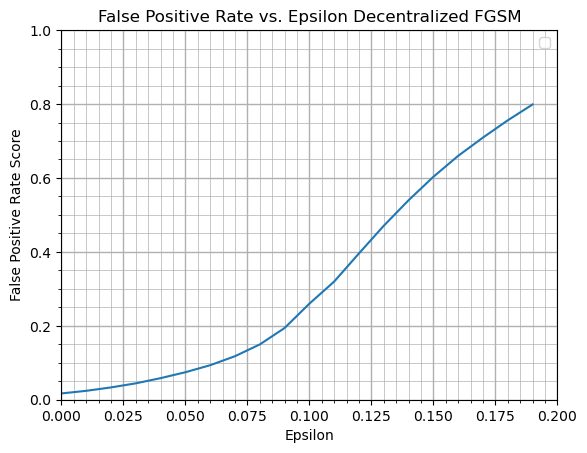

In [14]:
plt.plot(x_vals, y_vals)
display_metric = format_metric(metric)
display_plot(title=f"{display_metric} vs. Epsilon Decentralized FGSM", 
             display_metric=display_metric,
             x_max=0.2)